In [1]:
import os
import shutil
import random

# Set your base directory here
base_dir = 'Brain_Data_Organised'

# Classes
classes = ['Normal', 'Stroke']

# Split ratio
train_ratio = 0.8

# Create train/test directories
for split in ['train', 'test']:
    for cls in classes:
        os.makedirs(os.path.join(base_dir, split, cls), exist_ok=True)

for cls in classes:
    class_dir = os.path.join(base_dir, cls)
    files = os.listdir(class_dir)
    random.shuffle(files)
    
    split_index = int(len(files) * train_ratio)
    train_files = files[:split_index]
    test_files = files[split_index:]
    
    # Copy train files
    for file in train_files:
        src = os.path.join(class_dir, file)
        dst = os.path.join(base_dir, 'train', cls, file)
        shutil.copy2(src, dst)
    
    # Copy test files
    for file in test_files:
        src = os.path.join(class_dir, file)
        dst = os.path.join(base_dir, 'test', cls, file)
        shutil.copy2(src, dst)

print("Data split complete!")

Data split complete!


In [2]:
import numpy as np
import joblib
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D
from sklearn.model_selection import train_test_split

# Set your training and testing directories
train_dir = 'Brain_Data_Organised/train'
test_dir = 'Brain_Data_Organised/test'

# ImageDataGenerator with DenseNet's preprocessing
datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

# Load images from the training directory
train_data_gen = datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

# Load images from the testing directory
test_data_gen = datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

# Step 1: Load DenseNet121 as a feature extractor
base_model = DenseNet121(weights='imagenet', include_top=False)

# Add a Global Average Pooling layer to extract features
x = base_model.output
x = GlobalAveragePooling2D()(x)
feature_extractor = Model(inputs=base_model.input, outputs=x)

# Freeze the layers of DenseNet121
for layer in base_model.layers:
    layer.trainable = False

# Step 2: Extract features
def extract_features(data_generator):
    features = []
    labels = []
    
    for images, batch_labels in data_generator:
        feature_batch = feature_extractor.predict(images)
        features.append(feature_batch)
        labels.append(batch_labels)

        if len(features) * data_generator.batch_size >= data_generator.samples:
            break

    features = np.vstack(features)
    labels = np.vstack(labels)
    return features, labels

# Extract features for train and test
X_train_features, y_train_labels = extract_features(train_data_gen)
X_test_features, y_test_labels = extract_features(test_data_gen)

# Step 3: Save to joblib
joblib.dump((X_train_features, y_train_labels), 'train.joblib')
joblib.dump((X_test_features, y_test_labels), 'test.joblib')

# Step 4: Train/validation split
X_train, X_val, y_train, y_val = train_test_split(
    X_train_features, y_train_labels, test_size=0.2, random_state=42
)

joblib.dump((X_train, y_train), 'train_split.joblib')
joblib.dump((X_val, y_val), 'val_split.joblib')

print("Features extracted using DenseNet and saved to '.joblib' files.")


Found 1999 images belonging to 2 classes.
Found 502 images belonging to 2 classes.


1/1 [==============================] - 1s 677ms/step
Features extracted using DenseNet and saved to '.joblib' files.



Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.97      0.92       237
           1       0.95      0.81      0.87       163

    accuracy                           0.91       400
   macro avg       0.92      0.89      0.90       400
weighted avg       0.91      0.91      0.90       400



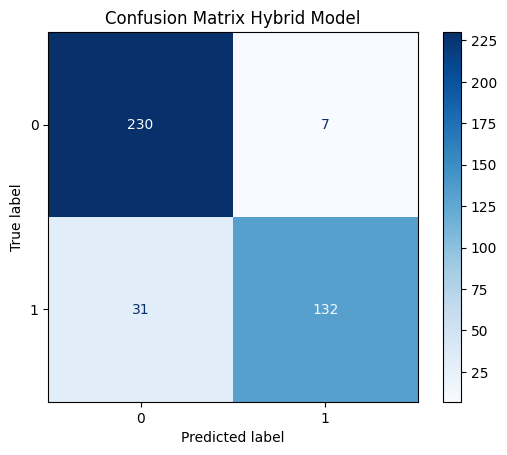

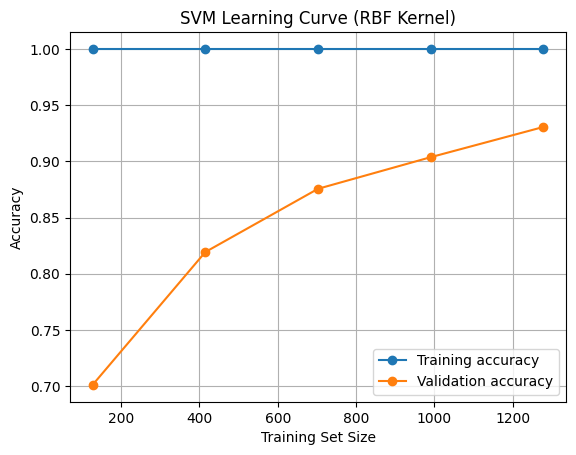

In [4]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import learning_curve
import joblib
import numpy as np
import matplotlib.pyplot as plt

# Load feature data
X_train, y_train = joblib.load('train_split.joblib')
X_val, y_val = joblib.load('val_split.joblib')

# Convert one-hot labels to class indices
y_train_classes = np.argmax(y_train, axis=1)
y_val_classes = np.argmax(y_val, axis=1)

# Define SVM pipeline with StandardScaler and RBF kernel
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=10, gamma='scale', probability=True))  # You can tune C and gamma
])

# Train the SVM model
svm_pipeline.fit(X_train, y_train_classes)

# Predict on validation data
y_val_pred = svm_pipeline.predict(X_val)

# Evaluate performance
print("\nClassification Report:")
print(classification_report(y_val_classes, y_val_pred))

# Confusion matrix
cm = confusion_matrix(y_val_classes, y_val_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix Hybrid Model')
plt.show()

# Learning curve
train_sizes, train_scores, val_scores = learning_curve(
    svm_pipeline, X_train, y_train_classes, cv=5, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 5), random_state=42
)

train_scores_mean = np.mean(train_scores, axis=1)
val_scores_mean = np.mean(val_scores, axis=1)

# Plotting learning curves
plt.figure()
plt.plot(train_sizes, train_scores_mean, 'o-', label="Training accuracy")
plt.plot(train_sizes, val_scores_mean, 'o-', label="Validation accuracy")
plt.title('SVM Learning Curve (RBF Kernel)')
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.legend(loc="best")
plt.grid(True)
plt.show()
